[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lalvim/DataMining/blob/main/notebooks/unidade_05/05_04_regressao_linear.ipynb)

# Unidade V — Classificação e Regressão

## Regressão linear simples e múltipla

**Carga estimada:** 3 horas  
**Pré-requisitos:** estatística descritiva, correlação, treino/teste e Python com pandas.

> **Pergunta norteadora:** como estimar um valor numérico por uma relação linear e verificar onde essa aproximação funciona ou falha?

O foco será a intuição geométrica, a leitura das previsões e a análise dos resíduos. A derivação matricial dos mínimos quadrados não faz parte do escopo desta disciplina.

## Objetivos de aprendizagem

Ao concluir este notebook, você será capaz de:

- distinguir alvo numérico de rótulo categórico;
- interpretar intercepto, coeficientes, previsão e resíduo;
- explicar intuitivamente o critério de mínimos quadrados;
- ajustar regressões lineares simples e múltiplas;
- comparar modelo e *baseline* com MAE, RMSE e $R^2$;
- examinar resíduos e reconhecer sinais de inadequação;
- identificar riscos de extrapolação, colinearidade e valores atípicos;
- evitar interpretação causal automática dos coeficientes.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

## 1. Classificação ou regressão?

A diferença está no significado do alvo:

| Pergunta | Alvo | Tarefa |
|---|---|---|
| O cliente cancelará? | categoria: sim ou não | classificação |
| Qual será o gasto mensal? | valor monetário | regressão |
| Qual espécie foi observada? | categoria | classificação |
| Qual será a temperatura? | número com unidade | regressão |

Um código numérico não basta para definir regressão. Se 1, 2 e 3 representam apenas categorias, as diferenças aritméticas entre eles não têm significado e o problema continua sendo de classificação.

## 2. A ideia da regressão linear

Na regressão simples, usamos um atributo $x$ para estimar um alvo numérico $y$:

$$
\hat{y}=b_0+b_1x.
$$

- $\hat{y}$ é a previsão;
- $b_0$ é o intercepto, previsão quando $x=0$;
- $b_1$ é o coeficiente angular, variação prevista em $y$ para uma unidade adicional de $x$.

Cada observação possui um **resíduo**:

$$
e_i=y_i-\hat{y}_i.
$$

Resíduo positivo significa que o valor observado ficou acima da previsão; resíduo negativo, abaixo. O método de mínimos quadrados escolhe os coeficientes que minimizam

$$
\sum_{i=1}^{n}(y_i-\hat{y}_i)^2.
$$

Ele penaliza fortemente erros grandes porque os resíduos são elevados ao quadrado.

## 3. Estudo de caso sintético: preço de imóveis

Cada linha representa um imóvel. O alvo `preco_mil` está em milhares de reais. Os dados são sintéticos e autorais; servem apenas para tornar os conceitos reproduzíveis.

In [2]:
rng = np.random.default_rng(RANDOM_STATE)
n_imoveis = 300

imoveis = pd.DataFrame({
    "area_m2": rng.uniform(35, 160, n_imoveis),
    "idade_anos": rng.uniform(0, 50, n_imoveis),
    "distancia_centro_km": rng.uniform(1, 25, n_imoveis),
})
imoveis["quartos"] = np.clip(
    np.rint(imoveis["area_m2"] / 35 + rng.normal(0, 0.6, n_imoveis)),
    1,
    5,
).astype(int)

ruido = rng.normal(0, 35, n_imoveis)
imoveis["preco_mil"] = (
    80
    + 3.2 * imoveis["area_m2"]
    + 25 * imoveis["quartos"]
    - 2.0 * imoveis["idade_anos"]
    - 4.5 * imoveis["distancia_centro_km"]
    + ruido
)

display(imoveis.head().round(2))
imoveis.describe().round(2)

,area_m2,idade_anos,distancia_centro_km,quartos,preco_mil
0,131.74,38.95,12.46,3,428.20
1,89.86,6.73,19.27,3,329.64
2,142.32,26.80,22.68,4,439.55
3,122.17,25.71,18.30,3,345.41
4,46.77,42.88,24.12,2,81.30


,area_m2,idade_anos,distancia_centro_km,quartos,preco_mil
count,300.00,300.00,300.00,300.00,300.00
mean,95.83,25.27,12.93,2.76,346.77
std,36.29,14.21,7.16,1.15,155.49
min,35.92,0.27,1.03,1.00,-3.23
25%,63.39,13.54,6.77,2.00,211.24
50%,94.88,25.67,13.05,3.00,336.74
75%,128.87,37.39,19.11,4.00,465.13
max,159.05,49.96,24.97,5.00,686.62


### Separação antes do ajuste

Assim como na classificação, o teste deve permanecer fora do treinamento. Usaremos 75% dos imóveis para ajustar os coeficientes e 25% para estimar o desempenho em casos não vistos.

A divisão é aleatória apenas porque este exemplo não possui tempo nem grupos espaciais explícitos. Em uma aplicação imobiliária real, separações por período ou região podem representar melhor o uso futuro.

In [3]:
indices_treino, indices_teste = train_test_split(
    imoveis.index,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

treino = imoveis.loc[indices_treino]
teste = imoveis.loc[indices_teste]

regressao_simples = LinearRegression()
regressao_simples.fit(
    treino[["area_m2"]],
    treino["preco_mil"],
)

intercepto_simples = regressao_simples.intercept_
coeficiente_area_simples = regressao_simples.coef_[0]

pd.DataFrame({
    "parametro": ["intercepto", "coeficiente de area_m2"],
    "valor": [intercepto_simples, coeficiente_area_simples],
}).round(3)

,parametro,valor
0,intercepto,-34.127
1,coeficiente de area_m2,3.978


### Interpretando a equação

O coeficiente de área representa a diferença média prevista no preço para mais 1 m² **dentro da relação ajustada e da faixa observada**. O intercepto é necessário para posicionar a reta, mas pode não ter interpretação prática: não há imóveis com área 0 m² na base.

O coeficiente descreve associação preditiva. Ele não prova que aumentar fisicamente a área, mantendo todo o restante do mundo igual, causaria exatamente a variação estimada. Área também se relaciona a quartos, localização e outras características.

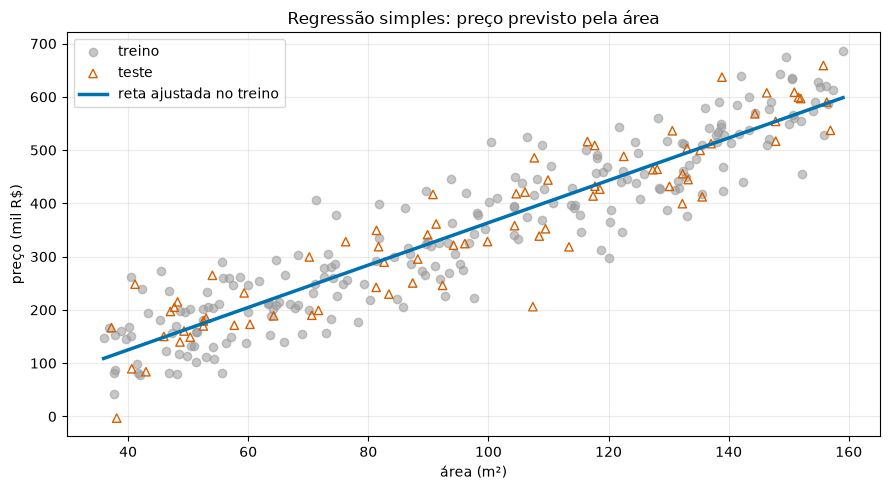

In [4]:
grade_area = pd.DataFrame({
    "area_m2": np.linspace(
        imoveis["area_m2"].min(),
        imoveis["area_m2"].max(),
        200,
    )
})
previsao_grade = regressao_simples.predict(grade_area)

fig, eixo = plt.subplots(figsize=(9, 5))
eixo.scatter(
    treino["area_m2"],
    treino["preco_mil"],
    color="#999999",
    alpha=0.55,
    label="treino",
)
eixo.scatter(
    teste["area_m2"],
    teste["preco_mil"],
    marker="^",
    facecolors="none",
    edgecolors="#D55E00",
    label="teste",
)
eixo.plot(
    grade_area["area_m2"],
    previsao_grade,
    color="#0072B2",
    linewidth=2.5,
    label="reta ajustada no treino",
)
eixo.set(
    title="Regressão simples: preço previsto pela área",
    xlabel="área (m²)",
    ylabel="preço (mil R$)",
)
eixo.legend()
eixo.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Regressão múltipla: várias informações ao mesmo tempo

Com $p$ atributos, a regressão linear assume:

$$
\hat{y}=b_0+b_1x_1+b_2x_2+\cdots+b_px_p.
$$

Cada coeficiente descreve a variação prevista quando aquele atributo aumenta uma unidade **mantendo os demais atributos do modelo constantes**. Essa frase é matemática, não causal.

A regressão múltipla pode reduzir resíduos ao incorporar informações omitidas pela regressão simples. Também pode ficar instável quando atributos carregam informação muito parecida, situação chamada **colinearidade**.

In [5]:
atributos_multiplos = [
    "area_m2",
    "quartos",
    "idade_anos",
    "distancia_centro_km",
]
X_treino = treino[atributos_multiplos]
X_teste = teste[atributos_multiplos]
y_treino = treino["preco_mil"]
y_teste = teste["preco_mil"]

baseline = DummyRegressor(strategy="mean")
regressao_multipla = LinearRegression()

baseline.fit(X_treino, y_treino)
regressao_multipla.fit(X_treino, y_treino)

previsoes = {
    "baseline: média do treino": baseline.predict(X_teste),
    "regressão simples": regressao_simples.predict(teste[["area_m2"]]),
    "regressão múltipla": regressao_multipla.predict(X_teste),
}

linhas_metricas = []
for nome, y_previsto in previsoes.items():
    linhas_metricas.append({
        "modelo": nome,
        "MAE": mean_absolute_error(y_teste, y_previsto),
        "RMSE": mean_squared_error(y_teste, y_previsto) ** 0.5,
        "R2": r2_score(y_teste, y_previsto),
    })

metricas = pd.DataFrame(linhas_metricas)
coeficientes = pd.DataFrame({
    "atributo": atributos_multiplos,
    "coeficiente": regressao_multipla.coef_,
})

display(metricas.round(3))
display(
    pd.concat([
        pd.DataFrame({
            "atributo": ["intercepto"],
            "coeficiente": [regressao_multipla.intercept_],
        }),
        coeficientes,
    ], ignore_index=True).round(3)
)

,modelo,MAE,RMSE,R2
0,baseline: média do treino,132.018,155.039,-0.002
1,regressão simples,44.539,56.386,0.867
2,regressão múltipla,26.386,33.345,0.954


,atributo,coeficiente
0,intercepto,69.467
1,area_m2,3.268
2,quartos,26.647
3,idade_anos,-1.993
4,distancia_centro_km,-4.633


## 5. Como avaliar previsões numéricas

Para $n$ casos:

$$
MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

é o erro absoluto médio. Mantém a unidade do alvo e responde: “em média, por quanto erramos em valor absoluto?”.

$$
RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
$$

também mantém a unidade, mas dá mais peso a erros grandes.

$$
R^2=1-\frac{\sum_i(y_i-\hat{y}_i)^2}
{\sum_i(y_i-\bar{y})^2}
$$

compara o erro do modelo com a previsão constante pela média. No teste:

- $R^2=1$: previsões perfeitas;
- $R^2=0$: desempenho quadrático equivalente ao uso da média;
- $R^2<0$: pior que prever a média do treino para esses casos.

Um $R^2$ alto não demonstra causalidade, não mede erro em reais e não garante que os resíduos sejam adequados.

## 6. Resíduos: onde o modelo erra?

Um bom resumo numérico não revela todos os padrões de erro. No gráfico de resíduos, procuramos uma nuvem aproximadamente sem estrutura ao redor de zero.

Sinais de atenção incluem:

- curva: relação não linear não capturada;
- funil: dispersão dos erros muda com o nível previsto;
- grupos: segmentos com comportamentos diferentes;
- pontos extremos: casos influentes ou erros de dados;
- tendência temporal: mudança de processo.

Os gráficos abaixo usam a regressão múltipla no conjunto de teste.

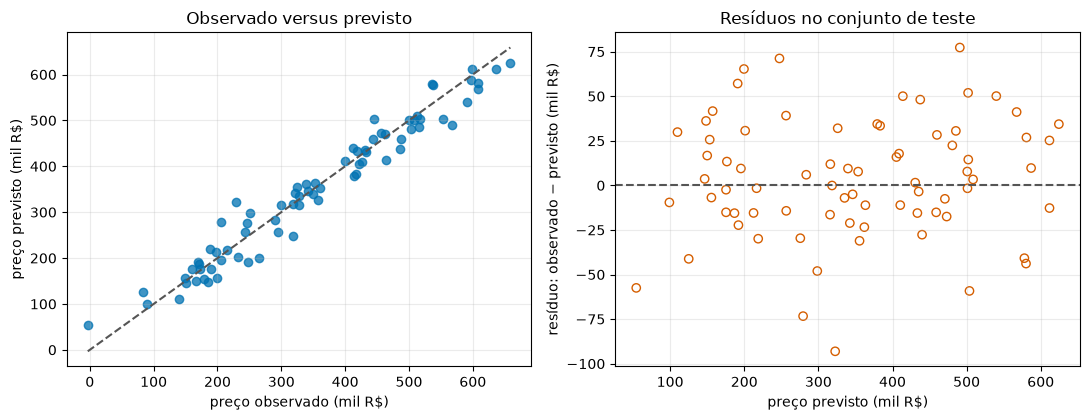

count    75.00
mean      3.80
std      33.35
min     -93.06
25%     -15.49
50%       3.34
75%      29.10
max      77.32
Name: residuo, dtype: float64

In [6]:
previsao_multipla = previsoes["regressão múltipla"]
residuos = y_teste.to_numpy() - previsao_multipla

fig, eixos = plt.subplots(1, 2, figsize=(11, 4.3))

eixos[0].scatter(
    y_teste,
    previsao_multipla,
    color="#0072B2",
    alpha=0.75,
)
limites = [
    min(y_teste.min(), previsao_multipla.min()),
    max(y_teste.max(), previsao_multipla.max()),
]
eixos[0].plot(limites, limites, "--", color="#555555")
eixos[0].set(
    title="Observado versus previsto",
    xlabel="preço observado (mil R$)",
    ylabel="preço previsto (mil R$)",
)

eixos[1].scatter(
    previsao_multipla,
    residuos,
    marker="o",
    facecolors="none",
    edgecolors="#D55E00",
)
eixos[1].axhline(0, linestyle="--", color="#555555")
eixos[1].set(
    title="Resíduos no conjunto de teste",
    xlabel="preço previsto (mil R$)",
    ylabel="resíduo: observado − previsto (mil R$)",
)

for eixo in eixos:
    eixo.grid(alpha=0.25)

plt.tight_layout()
plt.show()

pd.Series(residuos, name="residuo").describe().round(2)

## 7. Lendo coeficientes com suas unidades

Na regressão múltipla:

- o coeficiente de `area_m2` está em mil reais previstos por m²;
- o de `idade_anos`, em mil reais previstos por ano;
- o de `distancia_centro_km`, em mil reais previstos por quilômetro;
- o de `quartos` representa a diferença prevista por quarto adicional.

A interpretação “mantendo os demais constantes” pode ser pouco realista. Área e quartos, por exemplo, estão relacionados. Poucos imóveis grandes com apenas um quarto podem tornar certas combinações matematicamente possíveis, mas raras na realidade.

O sinal e a magnitude também dependem dos atributos incluídos, da faixa dos dados, das unidades e dos valores atípicos.

## 8. Interpolação não é extrapolação

**Interpolar** é prever dentro da faixa representada no treino. **Extrapolar** é prever fora dela, supondo que a mesma relação continue válida.

Compararemos um imóvel de 80 m² com outro de 250 m². A segunda área está muito além do máximo da base de treino. O modelo sempre consegue produzir um número, mas isso não significa que haja evidência para sustentá-lo.

In [7]:
casos = pd.DataFrame({
    "area_m2": [80, 250],
    "quartos": [2, 5],
    "idade_anos": [10, 10],
    "distancia_centro_km": [8, 8],
}, index=["interpolação", "extrapolação"])

casos["preco_previsto_mil"] = regressao_multipla.predict(
    casos[atributos_multiplos]
)
casos["dentro_da_faixa_de_area_do_treino"] = casos["area_m2"].between(
    treino["area_m2"].min(),
    treino["area_m2"].max(),
)
casos.round(2)

,area_m2,quartos,idade_anos,distancia_centro_km,preco_previsto_mil,dentro_da_faixa_de_area_do_treino
interpolação,80,2,10,8,327.2,True
extrapolação,250,5,10,8,962.7,False


### O número previsto não encerra a análise

Antes de usar uma regressão, pergunte:

1. a unidade de análise e o alvo estão bem definidos?
2. os atributos existiriam no momento da previsão?
3. treino e teste representam o uso futuro?
4. o modelo supera a média?
5. os erros são aceitáveis na unidade do problema?
6. há estrutura nos resíduos?
7. a previsão está dentro da região observada?
8. os coeficientes estão sendo descritos como associação, e não como causa?

Regressão linear é valiosa justamente por ser simples. Essa simplicidade torna claras tanto suas previsões quanto suas limitações.

## Atividades

> **U05-NB04-V01 — Verifique seu entendimento:** por que um alvo codificado com 0, 1 e 2 ainda pode exigir classificação em vez de regressão? Dê um exemplo categórico e um numérico.

> **U05-NB04-E01 — Exercício:** use o intercepto e o coeficiente da regressão simples exibidos no notebook para calcular manualmente o preço previsto de um imóvel de 80 m². Compare com a chamada do modelo e explique as unidades dos dois parâmetros.

> **U05-NB04-E02 — Cálculo de métricas:** para valores observados $[100,120,130]$ e previstos $[110,115,140]$, calcule resíduos, MAE, RMSE e $R^2$. Interprete os resultados na unidade do alvo.

> **U05-NB04-E03 — Comparação:** compare *baseline*, regressão simples e múltipla na tabela de teste. Quantifique a melhora da regressão múltipla em MAE e RMSE diante dos outros dois modelos e interprete o $R^2$ sem linguagem causal.

> **U05-NB04-E04 — Interpretação responsável:** escolha dois coeficientes da regressão múltipla e interprete sinal, magnitude e unidade. Depois explique por que a previsão do imóvel de 250 m² e os coeficientes não devem ser tratados como evidência causal.

## Síntese

- Regressão estima alvos numéricos; classificação prevê categorias.
- A reta ou superfície linear aproxima a relação entre atributos e alvo.
- Resíduo é a diferença entre valor observado e previsto.
- Mínimos quadrados penalizam mais fortemente resíduos grandes.
- MAE e RMSE permanecem na unidade do alvo; $R^2$ compara com a média.
- Resíduos ajudam a revelar padrões de erro escondidos pelas médias.
- Coeficientes dependem dos demais atributos e não demonstram causalidade.
- Extrapolação produz números, mas pode carecer de sustentação nos dados.

## Referências

- HAN, Jiawei; PEI, Jian; TONG, Hanghang. *Data Mining: Concepts and Techniques*. 4. ed. Cambridge: Morgan Kaufmann/Elsevier, 2023. Cap. 6, seção 6.5.1.
- SCIKIT-LEARN DEVELOPERS. *User Guide: Linear Models and regression metrics*. Documentação das bibliotecas utilizadas nos exemplos computacionais.